In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("data.csv", encoding="latin1")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.shape

(541909, 8)

In [11]:
df.duplicated().sum()

np.int64(5268)

In [12]:
(df.isnull().sum()/len(df))*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [13]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [14]:
df[df['CustomerID'].isnull()].shape

(135080, 8)

In [15]:
df = df.dropna(subset=['Description'])

In [16]:
df.shape
df.duplicated().sum()
(df.isnull().sum()/len(df))*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.724723
Country         0.000000
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(5268)

In [18]:
df.shape

(540455, 8)

In [19]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

In [20]:
(df['Quantity'] <= 0).sum()

np.int64(9762)

In [21]:
(df['UnitPrice'] <= 0).sum()

np.int64(1063)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [24]:
df = df[df['Quantity'] > 0]

In [25]:
df = df[df['UnitPrice'] > 0]

In [26]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [27]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.month_name()
df['Day_Name'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [28]:
df.shape

df.isnull().sum()

df.duplicated().sum()

(df['Quantity'] <= 0).sum()

(df['UnitPrice'] <= 0).sum()

np.int64(0)

In [29]:
# Total Revenue
df['Revenue'].sum()

# Total Orders
df['InvoiceNo'].nunique()

# Total Customers
df['CustomerID'].nunique()

# Average Order Value
df.groupby('InvoiceNo')['Revenue'].sum().mean()

np.float64(533.1718839679359)

In [30]:
# top 10 products
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [31]:
# top 10 countries
df.groupby('Country')['Revenue'] \
.sum() \
.sort_values(ascending=False) \
.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [32]:
# motnly revenue
df.groupby('Month_Name')['Revenue'] \
.sum() \
.sort_values(ascending=False)

Month_Name
November     1503866.780
December     1459243.060
October      1151263.730
September    1056435.192
May           769296.610
June          760547.010
August        757841.380
July          718076.121
March         716215.260
January       689811.610
April         536968.491
February      522545.560
Name: Revenue, dtype: float64

In [33]:
# top 10 customer
df.groupby('CustomerID')['Revenue'] \
.sum() \
.sort_values(ascending=False) \
.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

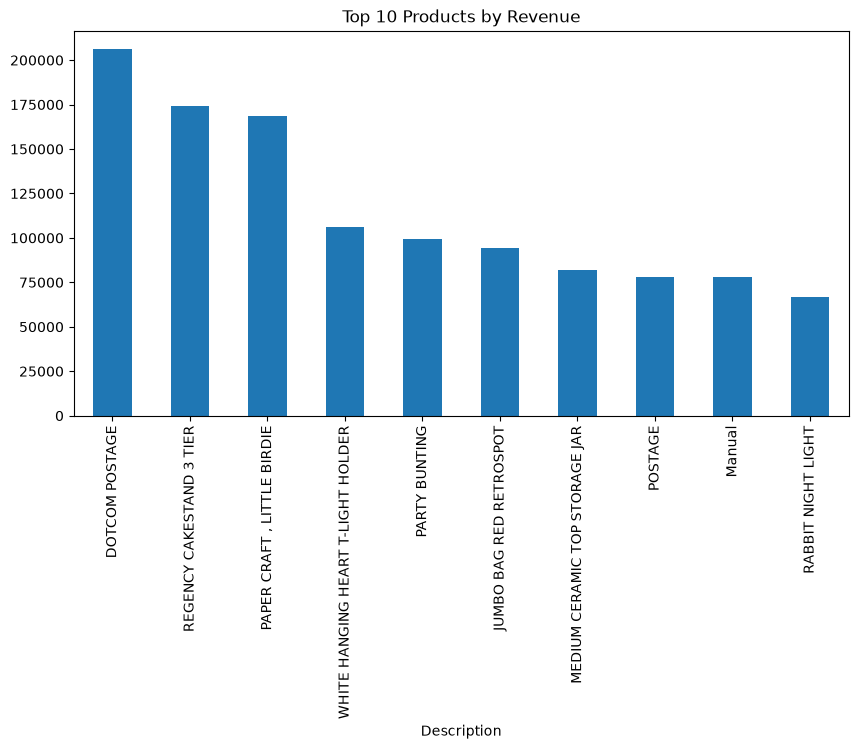

In [34]:
# top 10 products by revenue
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Products by Revenue')
plt.show()

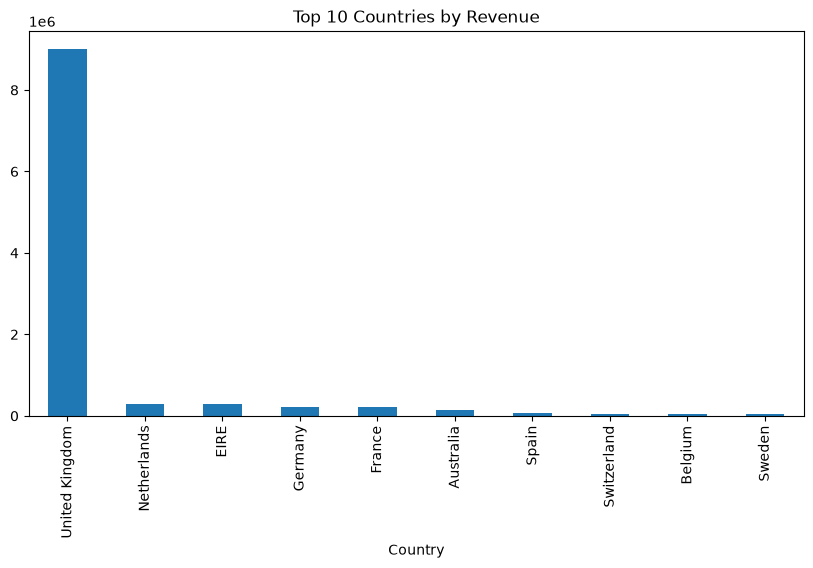

In [35]:
# Top 10 countries by Revenue
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Countries by Revenue')
plt.show()

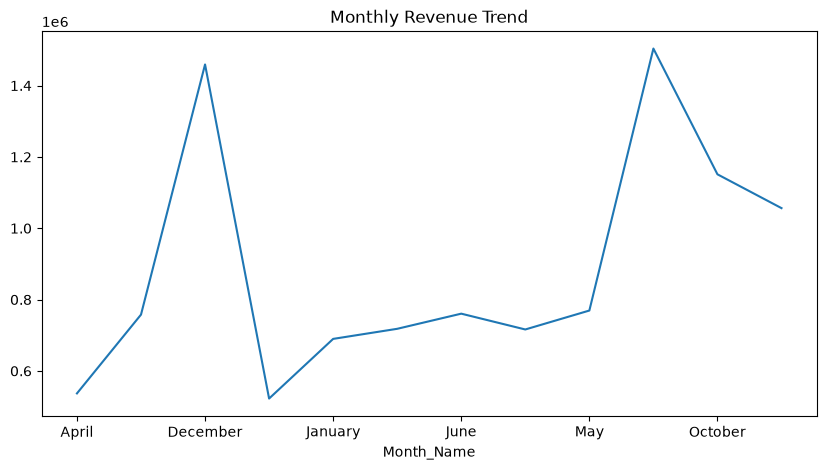

In [36]:
# Monthly revenue trend
monthly_sales = (
    df.groupby('Month_Name')['Revenue']
    .sum()
)

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.show()

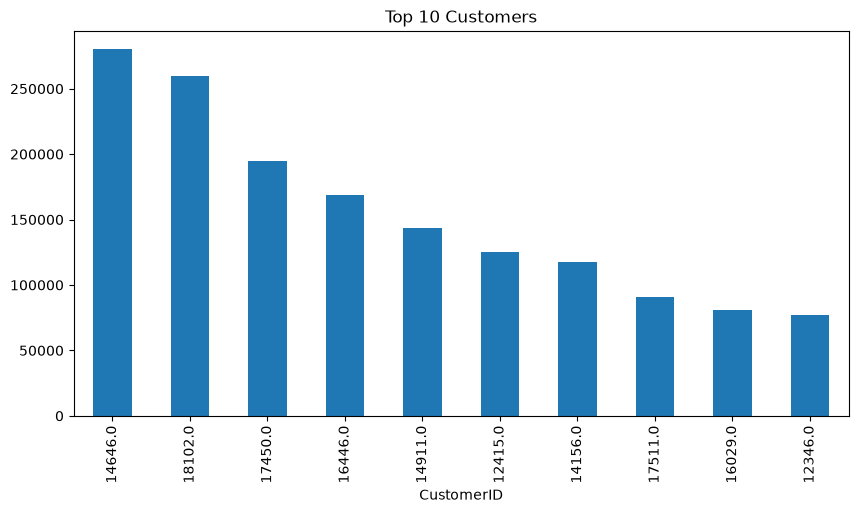

In [37]:
# Top 10 customer by revenue
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Customers')
plt.show()

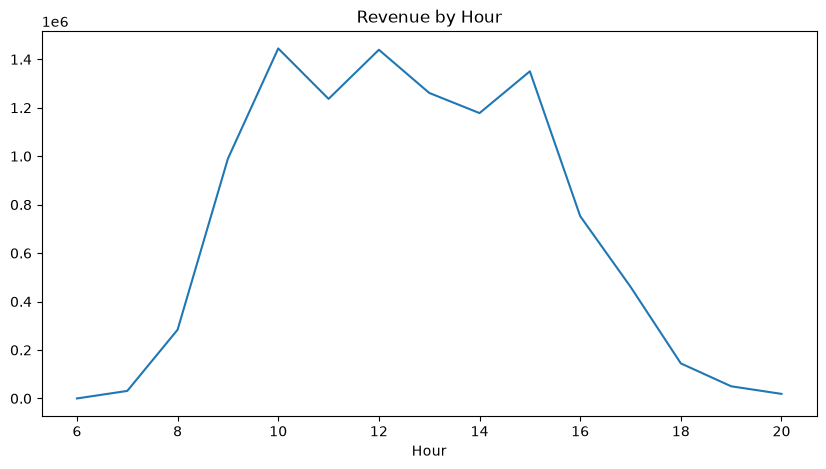

In [38]:
# Revenue by Hour
hourly_sales = (
    df.groupby('Hour')['Revenue']
    .sum()
)

hourly_sales.plot(kind='line', figsize=(10,5))
plt.title('Revenue by Hour')
plt.show()

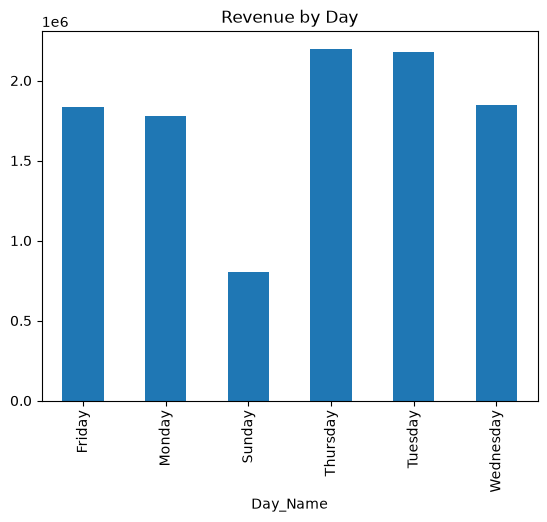

In [39]:
# Revenue by day of week 
daily_sales = (
    df.groupby('Day_Name')['Revenue']
    .sum()
)

daily_sales.plot(kind='bar')
plt.title('Revenue by Day')
plt.show()



### BUSINESS INSIGHTS

* The United Kingdom generated the highest revenue and accounted for the majority of total sales.
* A small group of products contributed significantly to overall revenue, indicating strong product concentration.
* Revenue was driven by a limited number of high-value customers, highlighting the importance of customer retention.
* Monthly sales trends revealed seasonal fluctuations in customer demand and purchasing behavior.
* Customer purchases were concentrated during specific hours of the day, suggesting peak shopping periods.
* Sales performance varied across weekdays, indicating differences in customer shopping patterns throughout the week.
* A small percentage of customers generated a disproportionately large share of total revenue.
* Product performance varied significantly, with top-selling products outperforming the rest by a large margin.
* International sales contributed to overall business growth, but revenue remained concentrated in a few countries.
* Understanding customer behavior and product demand can help improve inventory planning and marketing strategies.




In [40]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)

In [41]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "admin" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "ecommerce_data"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'ecommerce_data'.
